<a href="https://colab.research.google.com/github/Luis-Menezes/2026_2_CalculoNumerico/blob/main/CN_Atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


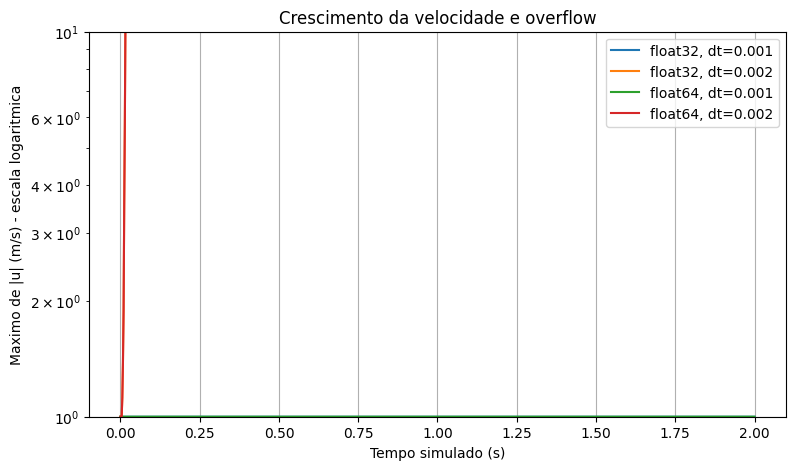

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

• Caso A: ∆t = 0,001 s, com r = 0,4;

• Caso B: ∆t = 0,002 s, com r = 0,8.

# Questão 1 - Avaliando a Estabilidade

Tomando a condição de estabilidade: $$r <= 0.5 $$
- Para o caso A:

  r = 0.4. Como r < 0.5, então o caso é estável

- Para o caso B:
  
  r = 0.8, portanto o caso é instável

# Questão 2 - Detecção de overflow.

In [ ]:
resultados = []

for tipo in (np.float32, np.float64):

    for dt in (0.001, 0.002):

        resultado = simular(
            dt=dt,
            tipo=tipo
        )

        # Verifica se houve overflow
        if resultado["falha"] is not None:
            overflow = "Sim"
            iteracao = resultado["falha"]
        else:
            overflow = "Não"
            iteracao = "-"

        resultados.append({
            "Tipo numérico": tipo.__name__,
            "Passo de tempo (s)": dt,
            "r": resultado["r"],
            "Overflow": overflow,
            "Iteração da falha": iteracao
        })


# ============================================================
# TABELA FINAL
# ============================================================

tabela = pd.DataFrame(resultados)

print("\nTabela da Questão 2:")
display(tabela)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add

Tabela da Questão 2:


,Tipo numérico,Passo de tempo (s),r,Overflow,Iteração da falha
0,float32,0.001,0.4,Não,-
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,-
3,float64,0.002,0.8,Sim,917


# Questão 3 - Interpretação Física

O gráfico para r = 0.8 não representa o comportamento físico esperado pois não segue o critério de estabilidade. Dessa forma, cada passo da iteração gera pequenas perturbações e erros nos cálculos, o que causa um "estouro" na velocidade e pode causar overflow

# Questão 4 - Capacidade de Representação

Não, a mudança do tipo numérico não elimina a instabilidade. O que define a estbilidade do sistema é o cálculo do parâmetro $r$. O tipo numérico ao realizar o cálculo faz com que a variável suporte números cada vez maiores, fazendo com que sejam necessários mais passos para que ocorra um overflow, porém o cálculo já não segue mais o modelo físico. Isso pode ser observado pelo número de passos até a falha. Para o caso ``float32``, a variável suportou apenas 121 passos, enquanto que para ``float64`` foram suportados 917 passos.

# Questão 5 - Refinamento da malha

In [ ]:
# Questão 5 - Refinamento da malha

pontos = 41
dt = 0.001

resultado = simular(
    dt=dt,
    tipo=np.float32,
    passos=2000,
    pontos=pontos
)

dy = 0.01 / (pontos - 1)
dt_max = dy**2 / (2 * 1e-4)

print("Número de pontos:", pontos)
print("Delta y =", dy, "m")
print("Delta t máximo(limite de estabilidade) =", dt_max, "s")
print("Delta t utilizado =", dt, "s")
print("r =", resultado["r"])
print("Falha =", resultado["falha"])

dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
Número de pontos: 41
Delta y = 0.00025 m
Delta t máximo(limite de estabilidade) = 0.00031249999999999995 s
Delta t utilizado = 0.001 s
r = 1.600000023841858
Falha = 56


Ao alterar as condições, temos que o limite de estabilidade agora é muito menor, sendo: $$ Δ_tmax = 3.12 × 10^{-4} s$$ Logo, o passo anterior de 0.001s é muito grande, o que causa uma instabilidade logo no passo 56, para ``float32``.


In [ ]:
# Teste com passo de tempo abaixo do limite

dt = 0.0002

resultado_estavel = simular(
    dt=dt,
    tipo=np.float32,
    passos=2000,
    pontos=41
)

print("Número de pontos:", pontos)
print("Delta y =", dy, "m")
print("Delta t máximo =", dt_max, "s")
print("Delta t utilizado =", dt, "s")
print("r =", resultado_estavel["r"])
print("Falha =", resultado_estavel["falha"])

dt=0.0002, float32: 2000 passos sem overflow.
Número de pontos: 41
Delta y = 0.00025 m
Delta t máximo = 0.00031249999999999995 s
Delta t utilizado = 0.0002 s
r = 0.3199999928474426
Falha = None


Para um passo de tempo abaixo do limite de estabilidade, temos um sistema estável.

# Questão 6 - Verificação do perfil de velocidade

dt=0.001, float64: 20000 passos sem overflow.
Número de pontos: 21
Delta t: 0.001 s
r: 0.4000000000000001
Tempo total simulado: 20.0 s
Erro máximo E_inf: 3.4416913763379853e-15 m/s


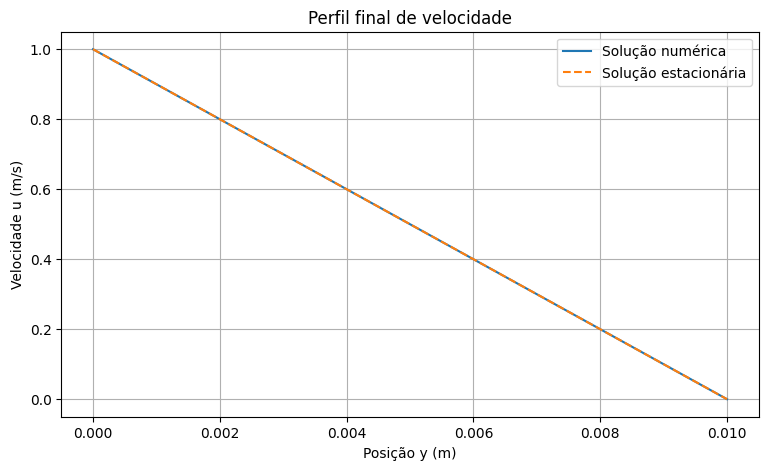

In [ ]:
# Parâmetros da simulação
pontos = 21
dt = 0.001
passos = 20000

# Executa a simulação
resultado = simular(
    dt=dt,
    tipo=np.float64,
    passos=passos,
    pontos=pontos
)

# Recupera os valores
y = resultado["y"]
u_final = resultado["u"]

# Parâmetros físicos
H = 0.01
U = 1.0

# Solução estacionária
u_est = U * (1 - y / H)

# Erro máximo
erro_maximo = np.max(np.abs(u_final - u_est))

# Tempo total simulado
tempo_total = passos * dt

print("Número de pontos:", pontos)
print("Delta t:", dt, "s")
print("r:", resultado["r"])
print("Tempo total simulado:", tempo_total, "s")
print("Erro máximo E_inf:", erro_maximo, "m/s")

# Gráfico
plt.figure(figsize=(9, 5))

plt.plot(
    y,
    u_final,
    label="Solução numérica"
)

plt.plot(
    y,
    u_est,
    "--",
    label="Solução estacionária"
)

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil final de velocidade")
plt.grid(True)
plt.legend()
plt.show()

Para a verificação do perfil de velocidade, foi utilizada uma malha com 21 pontos, passo de tempo $\Delta t=0,001,s$ e 20.000 passos, totalizando **20 segundos de tempo simulado**. Para essa configuração, o espaçamento é $\Delta y=0,0005,m$ e o parâmetro de estabilidade é $r=0,4$, satisfazendo a condição $r\leq0,5$.

O perfil final de velocidade obtido numericamente foi comparado com a solução estacionária $$u_{est}(y)=U(1-y/H)$$ Também foi calculado o erro máximo $E_\infty=\max_i|u_i-u_{est}(y_i)|$.

Como o tempo total simulado é de **20 segundos**, espera-se que a solução numérica esteja próxima do regime estacionário. A diferença entre o perfil numérico e o perfil estacionário pode ser avaliada pelo gráfico e pelo valor de $E_\infty$. O enunciado ressalta que eventuais diferenças podem incluir efeitos de um transiente que ainda não tenha sido completamente concluído.


# Questão 7 - Conclusão

Após os experimentos, podemos concluir que sempre é necessário observar o limite de estabilidade de um sistema antes de calcular numéricamente os resultados. Parâmetros como o refinamento da malha e passo de tempo indicam essa estabilidade.

Também é necessário observar os tipos numéricos usados nos cálculos, a fim de não mascarar alguns erros. Caso os passos no primeiro experimento fossem inferiores ao passo no qual o ``float64`` sofreu overflow, não saberíamos que o experimento representava valores incoerentes com a física real sem uma análise mais detalhada dos valores.

A alteração que corrige a causa da falha é a redução do passo de tempo após o refinamento da malha, de modo que o valor de $r$ volte a ficar dentro do limite de estabilidade.